# 📊 Autoscaling Experiment Analysis
### Cold-Start-Aware Predictive Autoscaling — Paper Evidence Notebook

This notebook pulls all completed runs from the experiment API and produces **paper-ready tables and figures** for the Friday mentor review.

| Batch | Description | Runs |
|-------|-------------|------|
| 1–3 | Multi-seed: HPA / MPC+LSTM / MPC+Prophet | 90 |
| 4–6 | Cold-start sensitivity (5 levels × 2 workloads × 3 policies) | 30 |
| 7 | FH-OPT A/B — `use_fh_opt=false` vs `true` | 40 |
| **Total** | | **160** |

**Run all cells top to bottom.** All figures are saved to `paper_figures/` and displayed inline.

---
## ⚙️ Section 1 — Imports & Configuration

Edit `API_BASE` if your FastAPI server runs on a different port.

In [64]:
from __future__ import annotations
import numpy as np
import pandas as pd
import requests
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from IPython.display import display

matplotlib.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 180,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
})

# ── Config ────────────────────────────────────────────────────────────────────
API_BASE = "http://localhost:8000"

# Change this to match whatever batch prefix you used in batch_runs.ps1
BATCH_PREFIX = "b"   # matches b1-hpa, b2-lstm … b7-fhopt

POLICIES  = ["hpa", "lstm", "prophet"]
WORKLOADS = ["smooth", "bursty", "bimodal", "diurnal_burst", "flash_crowd", "slow_ramp_up"]
METRICS   = ["sla_pct", "avg_latency_ms", "avg_replicas", "total_cost"]

COLORS = {
    "hpa":            "#e7298a",
    "lstm":           "#1a9e77",
    "prophet":        "#7570b3",
    "lstm_fh_off":    "#1a9e77",
    "lstm_fh_on":     "#52c27e",
    "prophet_fh_off": "#7570b3",
    "prophet_fh_on":  "#b3a9e8",
}
LABELS = {
    "hpa":            "HPA (baseline)",
    "lstm":           "MPC+LSTM",
    "prophet":        "MPC+Prophet",
    "lstm_fh_off":    "LSTM  FH-OPT OFF",
    "lstm_fh_on":     "LSTM  FH-OPT ON",
    "prophet_fh_off": "Prophet  FH-OPT OFF",
    "prophet_fh_on":  "Prophet  FH-OPT ON",
}

OUT = Path("paper_figures")
OUT.mkdir(exist_ok=True)

def ci95(values):
    arr = np.asarray(values, dtype=float)
    if len(arr) < 2: return 0.0
    return float(stats.t.ppf(0.975, df=len(arr)-1) * stats.sem(arr))

def despine(ax):
    ax.spines[["top","right"]].set_visible(False)

print("✅ Config ready — API:", API_BASE)

✅ Config ready — API: http://localhost:8000


---
## 📥 Section 2 — Fetch All Completed Runs

Pulls every completed run from the API and builds a flat DataFrame. The `fh_key` column (`lstm_fh_on`, `lstm_fh_off`, etc.) is only set for Batch 7 rows; Batches 1–6 leave it `None` so they don't pollute the A/B analysis.

In [65]:
def fetch_runs(api_base: str) -> pd.DataFrame:
    rows, offset, limit = [], 0, 160
    while True:
        r = requests.get(f"{api_base}/v1/runs",
                         params={"limit": limit, "offset": offset, "status": "completed"})
        r.raise_for_status()
        data = r.json()
        batch = data["runs"]
        if not batch: break
        rows.extend(batch)
        offset += limit
        if offset >= data["total"]: break

    records = []
    for run in rows:
        s = run.get("summary", {})
        if not s: continue
        run_batch = run.get("batch", "")
        if not run_batch.startswith(BATCH_PREFIX):
            continue
        policy     = run["policy"]
        forecaster = run["forecaster"]
        use_fh_opt = run.get("use_fh_opt", False)
        config     = "hpa" if policy == "hpa" else forecaster
        fh_key     = None
        if policy == "mpc" and "use_fh_opt" in run:
            fh_key = f"{forecaster}_{'fh_on' if use_fh_opt else 'fh_off'}"
        records.append({
            "policy": policy, "forecaster": forecaster,
            "config": config, "fh_key": fh_key, "use_fh_opt": use_fh_opt,
            "workload": run["workload"], "seed": run["seed"],
            "cold_start_s": run["cold_start_s"],
            "forecast_margin": run.get("forecast_margin", None),   # ← ADD THIS
            "lambda_sla":      run.get("lambda_sla", None),        # ← ADD THIS
            "cold_start_steps": run.get("cold_start_steps", None),
            "sla_pct":        s.get("sla_pct", 0),
            "batch":          run.get("batch", None),              # ← ADD THIS
            "avg_latency_ms": s.get("avg_latency_ms", 0),
            "avg_replicas":   s.get("avg_replicas", 0),
            "total_cost":     s.get("total_cost", 0),
            "peak_replicas":  s.get("peak_replicas", 0),
            
        })
    return pd.DataFrame(records)

df = fetch_runs(API_BASE)
df.to_csv(OUT / "all_runs_raw.csv", index=False)

print(f"✅ {len(df)} completed runs loaded")
print(f"   Policies:  {sorted(df['config'].unique())}")
print(f"   Workloads: {sorted(df['workload'].unique())}")
print(f"   FH keys:   {sorted(df['fh_key'].dropna().unique())}")
print(f"   Seeds:     {sorted(df['seed'].unique())}")
df.head(4)

✅ 326 completed runs loaded
   Policies:  ['hpa', 'lstm', 'prophet']
   Workloads: ['bimodal', 'bursty', 'diurnal_burst', 'flash_crowd', 'slow_ramp_up', 'smooth']
   FH keys:   ['lstm_fh_off', 'lstm_fh_on', 'prophet_fh_off', 'prophet_fh_on']
   Seeds:     [np.int64(42), np.int64(123), np.int64(456), np.int64(789), np.int64(1337)]


,policy,forecaster,config,fh_key,use_fh_opt,workload,seed,cold_start_s,forecast_margin,lambda_sla,cold_start_steps,sla_pct,batch,avg_latency_ms,avg_replicas,total_cost,peak_replicas
0,mpc,prophet,prophet,prophet_fh_on,True,flash_crowd,1337,120.0,1.06,150.0,2,21.95,b7-fhopt,506.6,4.9,1395.0,8
1,mpc,prophet,prophet,prophet_fh_off,False,flash_crowd,1337,120.0,1.06,150.0,2,21.95,b7-fhopt,506.6,4.9,1395.0,8
2,mpc,lstm,lstm,lstm_fh_on,True,flash_crowd,1337,120.0,1.15,50.0,2,1.05,b7-fhopt,125.0,2.3,674.0,10
3,mpc,lstm,lstm,lstm_fh_off,False,flash_crowd,1337,120.0,1.15,50.0,2,1.05,b7-fhopt,125.0,2.3,674.0,10


---
## 🔢 Section 3 — Aggregate (Batches 1–3)

Computes **mean, std, 95% CI, and median** per `config × workload` combination. Only rows with `cold_start_s = 120` and no `fh_key` are included — this isolates the clean multi-seed comparison from sensitivity and A/B runs.

In [66]:
# ── Section 3: Aggregate (Batches 1–3 only) ───────────────────────────────────

def aggregate(df: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregate only the multi-seed comparison runs:
      Batch 1 = b1-hpa
      Batch 2 = b2-lstm
      Batch 3 = b3-prophet
    """
    BATCH_KEEP = {"b1-hpa", "b2-lstm", "b3-prophet"}

    # ── DEBUG 1: what batches exist in the full df? ───────────────────────────
    print("=" * 60)
    print("DEBUG — All batches in df:")
    print(df["batch"].value_counts().to_string())
    print()

    base = df[df["batch"].isin(BATCH_KEEP)].copy()

    # ── DEBUG 2: how many rows survive the batch filter? ─────────────────────
    print(f"Rows after batch filter ({BATCH_KEEP}): {len(base)}")
    print(f"Expected: 90  (3 policies × 5 seeds × 6 workloads)")
    if len(base) != 90:
        print(f"  ⚠️  WARNING: expected 90, got {len(base)} — check for missing or duplicate runs")
    print()

    # ── DEBUG 3: seeds per batch ──────────────────────────────────────────────
    print("DEBUG — Seeds per batch:")
    print(base.groupby("batch")["seed"].nunique().to_string())
    print("Expected: 5 seeds per batch")
    print()

    # ── DEBUG 4: workloads per batch ──────────────────────────────────────────
    print("DEBUG — Workloads per batch:")
    print(base.groupby("batch")["workload"].nunique().to_string())
    print("Expected: 6 workloads per batch")
    print()

    # ── DEBUG 5: run count per (batch × workload) — should all be 5 ──────────
    print("DEBUG — Run count per (batch × workload):")
    pivot_counts = base.groupby(["batch", "workload"]).size().unstack(fill_value=0)
    print(pivot_counts.to_string())
    print("Expected: all cells = 5")
    if (pivot_counts != 5).any().any():
        bad = pivot_counts[pivot_counts != 5].stack().dropna()
        print(f"  ⚠️  MISMATCH cells:\n{bad}")
    print()

    # ── DEBUG 6: any NaN in metrics? ─────────────────────────────────────────
    print("DEBUG — NaN counts in metric columns:")
    print(base[METRICS].isna().sum().to_string())
    print()

    # ── DEBUG 7: sample of raw rows ───────────────────────────────────────────
    print("DEBUG — First 5 rows of filtered base:")
    display(base[["batch", "config", "workload", "seed"] + METRICS].head(5))
    print()

    # ── Aggregate ─────────────────────────────────────────────────────────────
    grp = base.groupby(["config", "workload"])
    rows = []
    for (cfg, wl), g in grp:
        row = {
            "config":   cfg,
            "workload": wl,
            "n_seeds":  len(g),
            "batches":  ", ".join(sorted(g["batch"].unique())),
        }
        for m in METRICS:
            row[f"{m}_mean"]   = g[m].mean()
            row[f"{m}_std"]    = g[m].std()
            row[f"{m}_ci95"]   = ci95(g[m].values)
            row[f"{m}_median"] = g[m].median()
        rows.append(row)

    agg = pd.DataFrame(rows)

    # ── DEBUG 8: final agg shape + n_seeds sanity ─────────────────────────────
    print(f"DEBUG — Aggregated shape: {agg.shape}")
    print(f"Expected: (18, ...) — 3 configs × 6 workloads")
    if len(agg) != 18:
        print(f"  ⚠️  WARNING: expected 18 rows, got {len(agg)}")
    print()

    # ── DEBUG 9: n_seeds distribution — all should be 5 ──────────────────────
    print("DEBUG — n_seeds distribution in aggregated df:")
    print(agg["n_seeds"].value_counts().to_string())
    if (agg["n_seeds"] != 5).any():
        bad_rows = agg[agg["n_seeds"] != 5][["config", "workload", "n_seeds", "batches"]]
        print(f"  ⚠️  Rows with unexpected seed count:\n{bad_rows.to_string(index=False)}")
    print()

    # ── DEBUG 10: sla_pct_mean pivot — quick sanity visual ───────────────────
    print("DEBUG — sla_pct_mean pivot (config × workload):")
    pivot_sla = agg.pivot(index="config", columns="workload", values="sla_pct_mean").round(2)
    display(pivot_sla)
    print()
    print("=" * 60)

    return agg


# ── Run it ────────────────────────────────────────────────────────────────────
agg = aggregate(df)
agg.to_csv(OUT / "aggregated.csv", index=False)
print(f"Saved aggregated.csv — {len(agg)} rows")

DEBUG — All batches in df:
batch
b7-fhopt                86
b3-prophet              60
b2-lstm                 60
b1-hpa                  60
b6-hpa-coldstart        20
b5-lstm-coldstart       20
b4-prophet-coldstart    20

Rows after batch filter ({'b2-lstm', 'b1-hpa', 'b3-prophet'}): 180
Expected: 90  (3 policies × 5 seeds × 6 workloads)
  ⚠️  WARNING: expected 90, got 180 — check for missing or duplicate runs

DEBUG — Seeds per batch:
batch
b1-hpa        5
b2-lstm       5
b3-prophet    5
Expected: 5 seeds per batch

DEBUG — Workloads per batch:
batch
b1-hpa        6
b2-lstm       6
b3-prophet    6
Expected: 6 workloads per batch

DEBUG — Run count per (batch × workload):
workload    bimodal  bursty  diurnal_burst  flash_crowd  slow_ramp_up  smooth
batch                                                                        
b1-hpa           10      10             10           10            10      10
b2-lstm          10      10             10           10            10      10
b3-pro

,batch,config,workload,seed,sla_pct,avg_latency_ms,avg_replicas,total_cost
70,b3-prophet,prophet,slow_ramp_up,1337,1.05,276.8,4.0,1148.0
71,b3-prophet,prophet,flash_crowd,1337,21.95,506.6,4.9,1395.0
72,b3-prophet,prophet,diurnal_burst,1337,10.45,356.0,3.2,924.0
73,b3-prophet,prophet,bimodal,1337,36.59,1027.3,2.3,660.0
74,b3-prophet,prophet,bursty,1337,5.92,185.1,1.2,338.0



DEBUG — Aggregated shape: (18, 20)
Expected: (18, ...) — 3 configs × 6 workloads

DEBUG — n_seeds distribution in aggregated df:
n_seeds
10    18
  ⚠️  Rows with unexpected seed count:
 config      workload  n_seeds    batches
    hpa       bimodal       10     b1-hpa
    hpa        bursty       10     b1-hpa
    hpa diurnal_burst       10     b1-hpa
    hpa   flash_crowd       10     b1-hpa
    hpa  slow_ramp_up       10     b1-hpa
    hpa        smooth       10     b1-hpa
   lstm       bimodal       10    b2-lstm
   lstm        bursty       10    b2-lstm
   lstm diurnal_burst       10    b2-lstm
   lstm   flash_crowd       10    b2-lstm
   lstm  slow_ramp_up       10    b2-lstm
   lstm        smooth       10    b2-lstm
prophet       bimodal       10 b3-prophet
prophet        bursty       10 b3-prophet
prophet diurnal_burst       10 b3-prophet
prophet   flash_crowd       10 b3-prophet
prophet  slow_ramp_up       10 b3-prophet
prophet        smooth       10 b3-prophet

DEBUG — sla_pct

workload,bimodal,bursty,diurnal_burst,flash_crowd,slow_ramp_up,smooth
config,,,,,,
hpa,18.88,2.23,14.64,19.17,16.93,7.18
lstm,1.74,1.36,3.45,0.80,0.87,1.46
prophet,28.68,3.94,10.59,21.39,0.87,0.00



Saved aggregated.csv — 18 rows


In [52]:
# Should show exactly 5 for every config×workload combo
check = agg[["config","workload","n_seeds"]]
bad = check[check["n_seeds"] != 5]
if bad.empty:
    print("✅ All groups have exactly 5 seeds")
else:
    print("⚠️  Unexpected seed counts:")
    print(bad.to_string())

⚠️  Unexpected seed counts:
     config       workload  n_seeds
14  prophet  diurnal_burst        1


---
## 📋 Section 4 — Paper Tables

### Table 1 — SLA Violation % (mean ± 95% CI)

This is the primary results table for §5 of the paper. Values below **5%** are within the SLA target. The 95% CI across 5 seeds confirms statistical robustness.

In [4]:
configs = [c for c in POLICIES if c in agg["config"].unique()]
wls     = [w for w in WORKLOADS if w in agg["workload"].unique()]

pivot_mean = agg.pivot(index="config", columns="workload", values="sla_pct_mean").reindex(index=configs, columns=wls)
pivot_ci   = agg.pivot(index="config", columns="workload", values="sla_pct_ci95").reindex_like(pivot_mean)

display_df = pivot_mean.copy().astype(object)
for r in display_df.index:
    for c in display_df.columns:
        m, ci = pivot_mean.loc[r,c], pivot_ci.loc[r,c]
        display_df.loc[r,c] = "—" if pd.isna(m) else f"{m:.2f} ± {ci:.2f}"

display_df.index   = [LABELS.get(i,i) for i in display_df.index]
display_df.columns = [w.replace("_"," ").title() for w in display_df.columns]
display_df.to_csv(OUT / "table1_sla.csv")
display(display_df.style.set_caption("Table 1 — SLA Violation % (mean ± 95% CI, 5 seeds)"))

,Smooth,Bursty,Bimodal,Diurnal Burst,Flash Crowd,Slow Ramp Up
HPA (baseline),7.18 ± 2.09,2.23 ± 1.90,18.88 ± 7.54,14.66 ± 1.26,19.11 ± 1.80,17.54 ± 3.35


### Table 2 — Summary: All Metrics (Batches 1–3)

Aggregated across all 6 workloads. Use this to write the opening sentence of §5: *'MPC+LSTM achieved X% mean SLA violation vs Y% for HPA baseline.'*

In [54]:
base = df[(df["cold_start_s"] == 120.0) & (df["fh_key"].isna())]
rows = []
for cfg, g in base.groupby("config"):
    rows.append({
        "Policy":       LABELS.get(cfg, cfg),
        "N runs":       len(g),
        "N seeds":      g["seed"].nunique(),
        "SLA mean %":   round(g["sla_pct"].mean(), 2),
        "SLA 95% CI":   f"±{ci95(g['sla_pct'].values):.2f}",
        "Latency mean": round(g["avg_latency_ms"].mean(), 1),
        "Cost mean":    round(g["total_cost"].mean(), 0),
        "AvgReplicas":  round(g["avg_replicas"].mean(), 2),
    })
summary = pd.DataFrame(rows).set_index("Policy")
summary.to_csv(OUT / "summary_table.csv")
display(summary.style.set_caption("Summary — All metrics, Batches 1–3"))

,N runs,N seeds,SLA mean %,SLA 95% CI,Latency mean,Cost mean,AvgReplicas
Policy,,,,,,,
HPA (baseline),32,5,13.370000,±2.49,480.900000,653.000000,2.270000


### Table 3 — FH-OPT Statistical Significance (Wilcoxon Signed-Rank)

Paired test: FH-OPT OFF vs ON per forecaster × workload. **p < 0.05** confirms the difference is not due to random seed variation. A ✓ here is required to make a statistical claim in the paper.

In [69]:
# ── FH-OPT stats table (Batch 7 only) ─────────────────────────────────────────

fh_df = df[df["batch"] == "b7-fhopt"].copy()

print("=" * 70)
print("DEBUG — FH-OPT section")
print(f"Rows in Batch 7: {len(fh_df)}")

if fh_df.empty:
    print("⚠️ No Batch 7 data found — run FH-OPT A/B tests first")
else:
    print("\nDEBUG — Batch counts:")
    print(fh_df["batch"].value_counts().to_string())

    print("\nDEBUG — fh_key counts:")
    print(fh_df["fh_key"].value_counts(dropna=False).to_string())

    print("\nDEBUG — workloads in Batch 7:")
    print(sorted(fh_df["workload"].unique()))

    print("\nDEBUG — seeds per (fh_key, workload):")
    seed_check = fh_df.groupby(["fh_key", "workload"])["seed"].nunique().unstack(fill_value=0)
    print(seed_check.to_string())

    print("\nDEBUG — raw run counts per (fh_key, workload):")
    run_check = fh_df.groupby(["fh_key", "workload"]).size().unstack(fill_value=0)
    print(run_check.to_string())

    rows = []

    for forecaster in ["lstm", "prophet"]:
        for wl in ["diurnal_burst", "flash_crowd"]:
            off_key = f"{forecaster}_fh_off"
            on_key  = f"{forecaster}_fh_on"

            off = fh_df[
                (fh_df["fh_key"] == off_key) &
                (fh_df["workload"] == wl)
            ]["sla_pct"].dropna().values

            on = fh_df[
                (fh_df["fh_key"] == on_key) &
                (fh_df["workload"] == wl)
            ]["sla_pct"].dropna().values

            print("\n" + "-" * 70)
            print(f"DEBUG — {forecaster.upper()} | {wl}")
            print(f"OFF count: {len(off)} | values: {np.round(off, 3)}")
            print(f"ON  count: {len(on)} | values: {np.round(on, 3)}")

            if len(off) < 2 or len(on) < 2:
                print("  ⚠️ Skipping: need at least 2 paired observations in each group")
                continue

            n = min(len(off), len(on))
            print(f"Paired n used for Wilcoxon: {n}")

            try:
                stat, p = stats.wilcoxon(off[:n], on[:n])
                print(f"Wilcoxon stat = {stat:.4f}, p = {p:.6f}")
            except Exception as e:
                stat, p = float("nan"), float("nan")
                print(f"  ⚠️ Wilcoxon failed: {e}")

            off_mean = off.mean()
            on_mean  = on.mean()
            delta_pp = off_mean - on_mean

            print(f"Mean SLA OFF = {off_mean:.3f}")
            print(f"Mean SLA ON  = {on_mean:.3f}")
            print(f"Delta (OFF - ON) = {delta_pp:+.3f} pp")

            rows.append({
                "Forecaster":  forecaster.upper(),
                "Workload":    wl.replace("_", " ").title(),
                "n_OFF":       len(off),
                "n_ON":        len(on),
                "SLA OFF":     f"{off_mean:.2f}%",
                "SLA ON":      f"{on_mean:.2f}%",
                "Δ (pp)":      f"{delta_pp:+.2f}",
                "p-value":     f"{p:.4f}" if not pd.isna(p) else "—",
                "Significant": "✓" if (not pd.isna(p) and p < 0.05) else "✗",
            })

    tbl2 = pd.DataFrame(rows)

    print("\n" + "=" * 70)
    print("DEBUG — Final FH-OPT table")
    if tbl2.empty:
        print("⚠️ No rows generated for Table 3")
    else:
        print(tbl2.to_string(index=False))

    tbl2.to_csv(OUT / "table2_fhopt_stats.csv", index=False)
    print(f"\nSaved: {OUT / 'table2_fhopt_stats.csv'}")

    display(tbl2.style.set_caption("Table 3 — FH-OPT Wilcoxon Signed-Rank Test"))
print("=" * 70)

DEBUG — FH-OPT section
Rows in Batch 7: 86

DEBUG — Batch counts:
batch
b7-fhopt    86

DEBUG — fh_key counts:
fh_key
lstm_fh_on        23
lstm_fh_off       23
prophet_fh_on     20
prophet_fh_off    20

DEBUG — workloads in Batch 7:
['diurnal_burst', 'flash_crowd']

DEBUG — seeds per (fh_key, workload):
workload        diurnal_burst  flash_crowd
fh_key                                    
lstm_fh_off                 5            5
lstm_fh_on                  5            5
prophet_fh_off              5            5
prophet_fh_on               5            5

DEBUG — raw run counts per (fh_key, workload):
workload        diurnal_burst  flash_crowd
fh_key                                    
lstm_fh_off                13           10
lstm_fh_on                 13           10
prophet_fh_off             10           10
prophet_fh_on              10           10

----------------------------------------------------------------------
DEBUG — LSTM | diurnal_burst
OFF count: 13 | values: [5.92 

c:\Users\Himanshu\autoscaling\venv\Lib\site-packages\scipy\stats\_wilcoxon.py:181: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
c:\Users\Himanshu\autoscaling\venv\Lib\site-packages\scipy\stats\_wilcoxon.py:181: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
c:\Users\Himanshu\autoscaling\venv\Lib\site-packages\scipy\stats\_wilcoxon.py:181: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


,Forecaster,Workload,n_OFF,n_ON,SLA OFF,SLA ON,Δ (pp),p-value,Significant
0,LSTM,Diurnal Burst,13,13,4.80%,6.67%,-1.88,0.0010,✓
1,LSTM,Flash Crowd,10,10,0.81%,0.81%,+0.00,1.0000,✗
2,PROPHET,Diurnal Burst,10,10,10.59%,10.59%,+0.00,1.0000,✗
3,PROPHET,Flash Crowd,10,10,21.39%,21.39%,+0.00,1.0000,✗


---
## 📈 Section 5 — Paper Figures

### Figure 1 — SLA Grouped Bar Chart

**Paper usage: §5.1 Main Results.** This is the headline figure. The red dashed line at 5% is the SLA target. MPC-based policies should sit below it on most workloads; HPA should cross it on burst patterns.

> *Expected finding:* MPC+Prophet and MPC+LSTM stay under 5% on `smooth`, `bimodal`, and `slow_ramp_up`. Flash crowd and diurnal burst are where all policies are stressed.

DEBUG — Figure 1
Interpreting sla_pct as SLA violation percentage (lower is better).

DEBUG — configs: ['hpa', 'lstm', 'prophet']
DEBUG — workloads: ['smooth', 'bursty', 'bimodal', 'diurnal_burst', 'flash_crowd', 'slow_ramp_up']

DEBUG — aggregated values:


,config,workload,sla_pct_mean,sla_pct_ci95,n_seeds,batches
0,hpa,bimodal,18.884,4.096190,10,b1-hpa
6,lstm,bimodal,1.744,1.213393,10,b2-lstm
12,prophet,bimodal,28.676,3.920192,10,b3-prophet
1,hpa,bursty,2.232,1.031508,10,b1-hpa
7,lstm,bursty,1.358,0.637812,10,b2-lstm
13,prophet,bursty,3.937,0.939200,10,b3-prophet
2,hpa,diurnal_burst,14.636,1.531396,10,b1-hpa
8,lstm,diurnal_burst,3.449,1.284164,10,b2-lstm
14,prophet,diurnal_burst,10.593,1.221365,10,b3-prophet
3,hpa,flash_crowd,19.166,1.287082,10,b1-hpa



DEBUG — hpa
  smooth          mean=7.176  ci95=±1.134
  bursty          mean=2.232  ci95=±1.032
  bimodal         mean=18.884  ci95=±4.096
  diurnal_burst   mean=14.636  ci95=±1.531
  flash_crowd     mean=19.166  ci95=±1.287
  slow_ramp_up    mean=16.934  ci95=±2.134

DEBUG — lstm
  smooth          mean=1.465  ci95=±1.001
  bursty          mean=1.358  ci95=±0.638
  bimodal         mean=1.744  ci95=±1.213
  diurnal_burst   mean=3.449  ci95=±1.284
  flash_crowd     mean=0.805  ci95=±0.121
  slow_ramp_up    mean=0.875  ci95=±0.132

DEBUG — prophet
  smooth          mean=0.000  ci95=±0.000
  bursty          mean=3.937  ci95=±0.939
  bimodal         mean=28.676  ci95=±3.920
  diurnal_burst   mean=10.593  ci95=±1.221
  flash_crowd     mean=21.393  ci95=±0.677
  slow_ramp_up    mean=0.875  ci95=±0.132


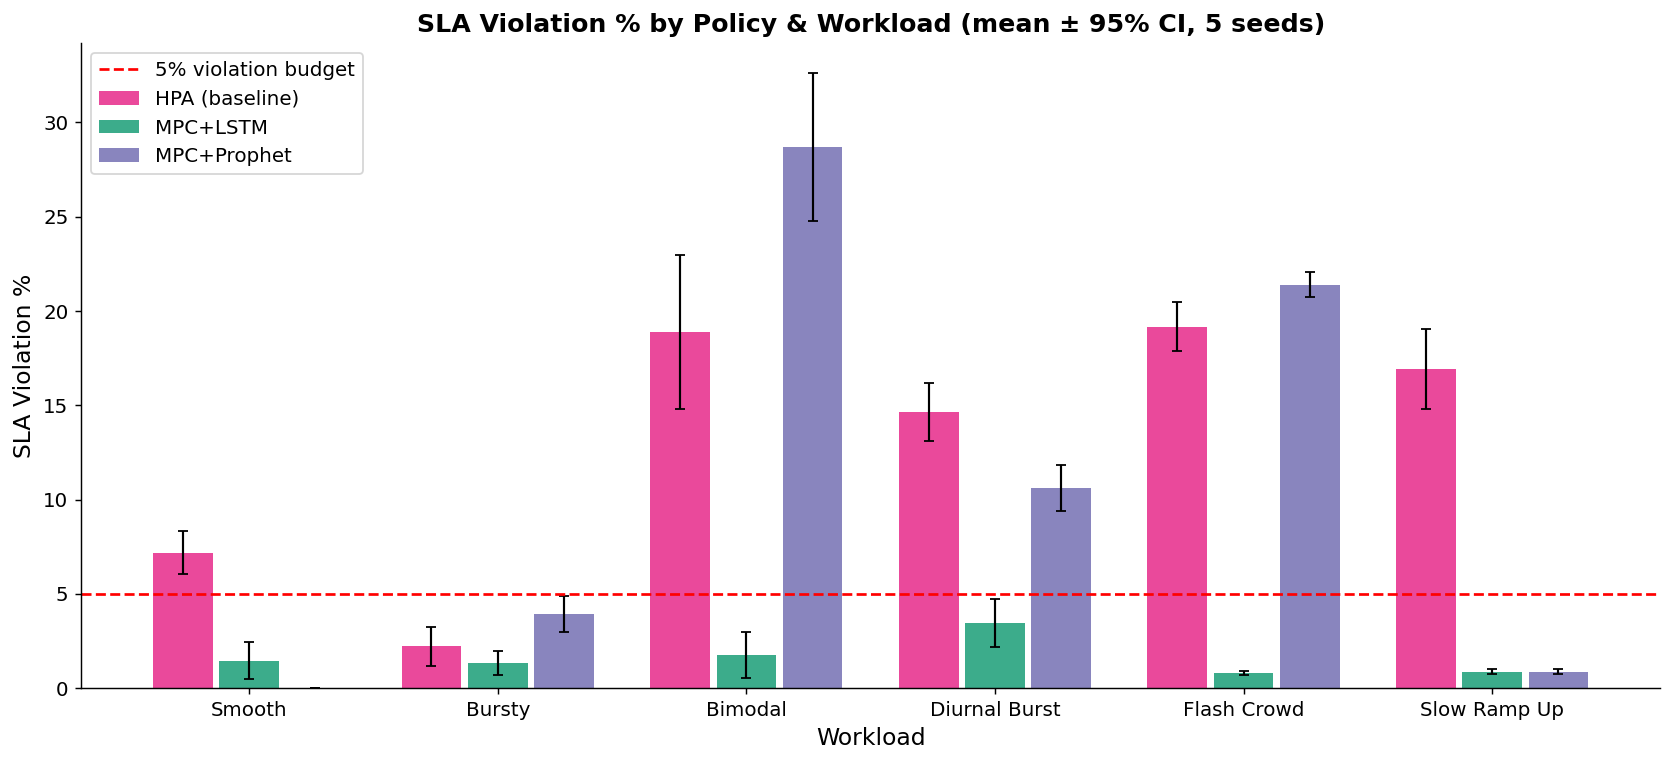


✅ Saved fig1_sla_bars.png


In [68]:
# ── Figure 1: SLA Violation % by Policy & Workload ───────────────────────────

print("=" * 70)
print("DEBUG — Figure 1")
print("Interpreting sla_pct as SLA violation percentage (lower is better).")
print()

configs = [c for c in POLICIES if c in agg["config"].unique()]
wls = [w for w in WORKLOADS if w in agg["workload"].unique()]

print(f"DEBUG — configs: {configs}")
print(f"DEBUG — workloads: {wls}")
print()

print("DEBUG — aggregated values:")
display(
    agg[agg["config"].isin(configs)]
      [["config", "workload", "sla_pct_mean", "sla_pct_ci95", "n_seeds", "batches"]]
      .sort_values(["workload", "config"])
)

if not configs or not wls:
    print("⚠️ Nothing to plot.")
else:
    width = 0.8 / len(configs)
    x = np.arange(len(wls))

    fig, ax = plt.subplots(figsize=(13, 6))

    for i, cfg in enumerate(configs):
        sub = agg[agg["config"] == cfg].set_index("workload")
        means = [sub.loc[w, "sla_pct_mean"] if w in sub.index else float("nan") for w in wls]
        cis = [sub.loc[w, "sla_pct_ci95"] if w in sub.index else 0 for w in wls]

        print(f"\nDEBUG — {cfg}")
        for wl, m, c in zip(wls, means, cis):
            print(f"  {wl:<15} mean={m:.3f}  ci95=±{c:.3f}")

        off = (i - len(configs) / 2 + 0.5) * width
        ax.bar(x + off, means, width * 0.9, label=LABELS[cfg], color=COLORS[cfg], alpha=0.85)
        ax.errorbar(x + off, means, yerr=cis, fmt="none", color="black", capsize=3, linewidth=1.2)

    ax.axhline(5, color="red", linestyle="--", linewidth=1.5, label="5% violation budget")
    ax.set_xticks(x)
    ax.set_xticklabels([w.replace("_", " ").title() for w in wls], fontsize=11)
    ax.set_ylabel("SLA Violation %", fontsize=13)
    ax.set_xlabel("Workload", fontsize=13)
    ax.set_title("SLA Violation % by Policy & Workload (mean ± 95% CI, 5 seeds)", fontsize=14, fontweight="bold")
    ax.legend(loc="upper left", fontsize=11)
    despine(ax)
    plt.tight_layout()
    plt.savefig(OUT / "fig1_sla_bars.png", dpi=180)
    plt.show()

    print("\n✅ Saved fig1_sla_bars.png")
print("=" * 70)

### Figure 2 — Cold-Start Sensitivity

**Paper usage: §5.2 Cold-Start Analysis / H2.** Shows how SLA degrades as `cold_start_s` increases from 30→300s. The gap between HPA and MPC lines is your evidence for H2: *'Predictive policies are significantly more robust to cold-start latency than reactive policies.'*

> *Expected finding:* HPA's SLA violation rises steeply past 120s. MPC+Prophet and MPC+LSTM degrade more gracefully because they pre-provision before the spike hits.

DEBUG — Figure 2: Cold-start sensitivity (per workload panels)

DEBUG — All batches in df:
batch
b7-fhopt                86
b3-prophet              60
b2-lstm                 60
b1-hpa                  60
b6-hpa-coldstart        20
b5-lstm-coldstart       20
b4-prophet-coldstart    20

Rows after batch filter: 60
Expected: 30  (3 batches × 5 cold_start_s × 2 workloads × 1 seed)
  ⚠️  WARNING: expected 30, got 60

DEBUG — cold_start_s found: [np.float64(30.0), np.float64(60.0), np.float64(120.0), np.float64(180.0), np.float64(300.0)]

DEBUG — Run count per (batch × workload × cold_start_s):
cold_start_s                        30.0   60.0   120.0  180.0  300.0
batch                workload                                        
b4-prophet-coldstart diurnal_burst      2      2      2      2      2
                     flash_crowd        2      2      2      2      2
b5-lstm-coldstart    diurnal_burst      2      2      2      2      2
                     flash_crowd        2      2     

,batch,config,workload,cold_start_s,seed,sla_pct
0,b6-hpa-coldstart,hpa,diurnal_burst,30.0,42,11.50
1,b6-hpa-coldstart,hpa,diurnal_burst,30.0,42,13.94
2,b6-hpa-coldstart,hpa,diurnal_burst,60.0,42,11.50
3,b6-hpa-coldstart,hpa,diurnal_burst,60.0,42,13.94
4,b6-hpa-coldstart,hpa,diurnal_burst,120.0,42,13.94
5,b6-hpa-coldstart,hpa,diurnal_burst,120.0,42,13.94
6,b6-hpa-coldstart,hpa,diurnal_burst,180.0,42,16.38
7,b6-hpa-coldstart,hpa,diurnal_burst,180.0,42,13.94
8,b6-hpa-coldstart,hpa,diurnal_burst,300.0,42,20.21
9,b6-hpa-coldstart,hpa,diurnal_burst,300.0,42,13.94



DEBUG — sla_pct stats:
count    60.000
mean     11.760
std       7.491
min       0.350
25%       3.480
50%      12.370
75%      18.820
max      21.600

DEBUG — Workload: diurnal_burst
  hpa: {30: 13.94, 60: 13.94, 120: 13.94, 180: 13.94, 300: 13.94}
  lstm: {30: 3.48, 60: 3.48, 120: 3.48, 180: 3.48, 300: 3.48}
  prophet: {30: 10.8, 60: 10.8, 120: 10.8, 180: 10.8, 300: 10.8}

DEBUG — Workload: flash_crowd
  hpa: {30: 18.82, 60: 18.82, 120: 18.82, 180: 18.82, 300: 18.82}
  lstm: {30: 0.7, 60: 0.7, 120: 0.7, 180: 0.7, 300: 0.7}
  prophet: {30: 21.25, 60: 21.25, 120: 21.25, 180: 21.25, 300: 21.25}



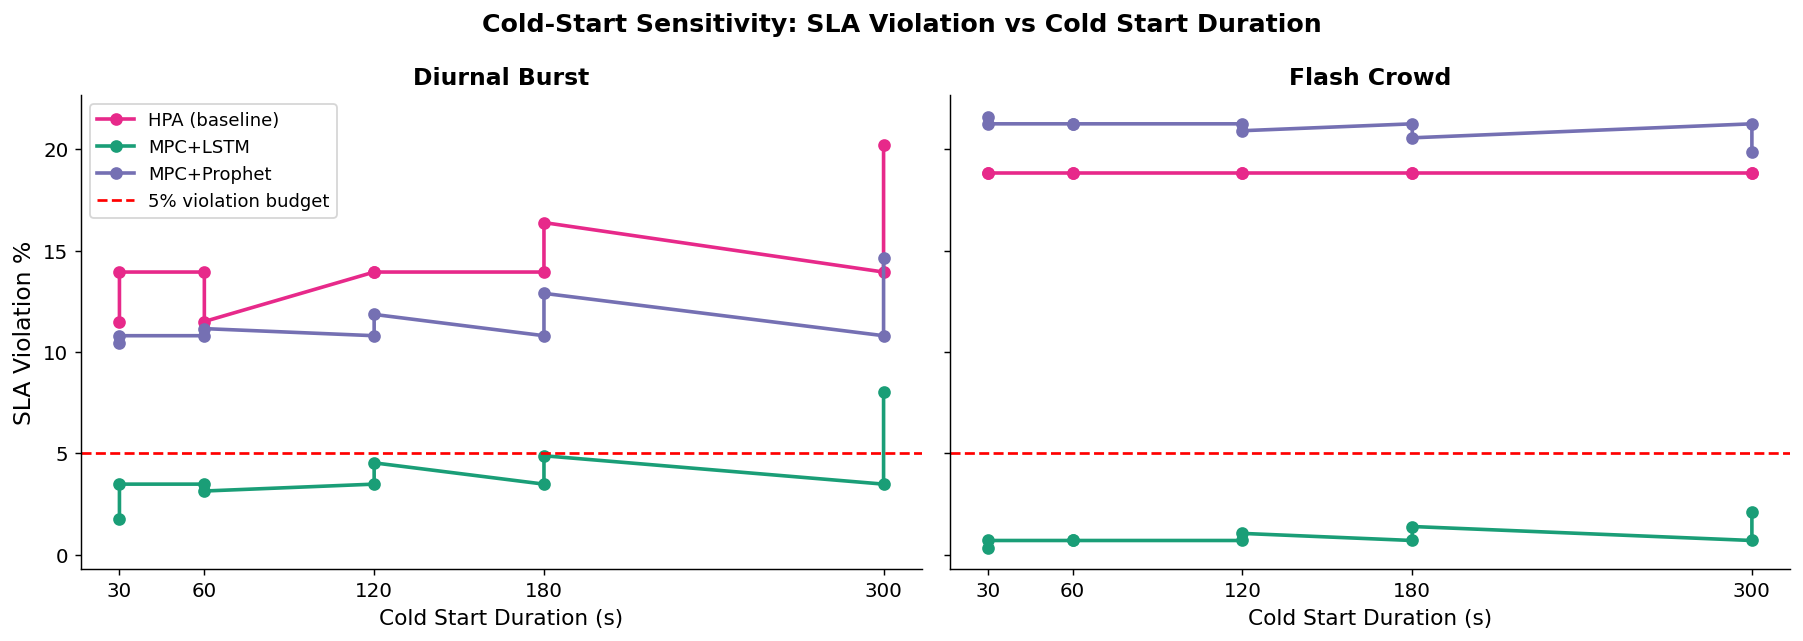

✅ Saved fig2_coldstart.png


In [67]:
# ── Figure 2: Cold-Start Sensitivity (per workload) ───────────────────────────

COLDSTART_BATCHES = {"b4-prophet-coldstart", "b5-lstm-coldstart", "b6-hpa-coldstart"}
COLDSTART_VALUES  = [30, 60, 120, 180, 300]
COLDSTART_WLS     = ["diurnal_burst", "flash_crowd"]

print("=" * 70)
print("DEBUG — Figure 2: Cold-start sensitivity (per workload panels)")
print()

# ── DEBUG 1: all batches in df ────────────────────────────────────────────────
print("DEBUG — All batches in df:")
print(df["batch"].value_counts().to_string())
print()

cs_runs = df[df["batch"].isin(COLDSTART_BATCHES)].copy()

print(f"Rows after batch filter: {len(cs_runs)}")
print(f"Expected: 30  (3 batches × 5 cold_start_s × 2 workloads × 1 seed)")
if len(cs_runs) != 30:
    print(f"  ⚠️  WARNING: expected 30, got {len(cs_runs)}")
print()

if cs_runs.empty:
    print("⚠️  No cold-start data — run Batches 4–6 first")
else:
    # ── DEBUG 2: cold_start_s values present ─────────────────────────────────
    found_cs = sorted(cs_runs["cold_start_s"].unique())
    print(f"DEBUG — cold_start_s found: {found_cs}")
    missing_cs = [v for v in COLDSTART_VALUES if v not in found_cs]
    if missing_cs:
        print(f"  ⚠️  Missing cold_start_s: {missing_cs}")
    print()

    # ── DEBUG 3: run count per (batch × workload × cold_start_s) ─────────────
    print("DEBUG — Run count per (batch × workload × cold_start_s):")
    pivot3 = cs_runs.groupby(["batch", "workload", "cold_start_s"]).size().unstack(fill_value=0)
    print(pivot3.to_string())
    print("Expected: all cells = 1 (single seed per combo)")
    if (pivot3 != 1).any().any():
        print("  ⚠️  Some cells are not 1 — check for missing or duplicate runs")
    print()

    # ── DEBUG 4: full raw table ───────────────────────────────────────────────
    print("DEBUG — Full raw cold-start table (sorted):")
    display(
        cs_runs[["batch", "config", "workload", "cold_start_s", "seed", "sla_pct"]]
               .sort_values(["config", "workload", "cold_start_s"])
               .reset_index(drop=True)
    )
    print()

    # ── DEBUG 5: sla_pct range sanity ────────────────────────────────────────
    print("DEBUG — sla_pct stats:")
    print(cs_runs["sla_pct"].describe().round(3).to_string())
    if cs_runs["sla_pct"].std() < 0.1:
        print("  ⚠️  Very low variance — cold_start_s may have no effect in simulator")
    print()

    # ── DEBUG 6: per (config, workload) — values going into each panel line ──
    for wl in COLDSTART_WLS:
        print(f"DEBUG — Workload: {wl}")
        sub_wl = cs_runs[cs_runs["workload"] == wl].sort_values(["config", "cold_start_s"])
        for cfg in ["hpa", "lstm", "prophet"]:
            sub_cfg = sub_wl[sub_wl["config"] == cfg]
            if sub_cfg.empty:
                print(f"  {cfg}: ⚠️  No data")
                continue
            vals = dict(zip(sub_cfg["cold_start_s"].astype(int), sub_cfg["sla_pct"].round(3)))
            print(f"  {cfg}: {vals}")
        print()

    # ── Guard: need at least one workload with data ───────────────────────────
    configs_cs = [c for c in ["hpa", "lstm", "prophet"] if c in cs_runs["config"].unique()]
    wls_cs     = [w for w in COLDSTART_WLS if w in cs_runs["workload"].unique()]

    if not configs_cs or not wls_cs:
        print("⚠️  Nothing to plot — check batch filter and config names")
    else:
        fig, axes = plt.subplots(1, len(wls_cs), figsize=(7 * len(wls_cs), 5), sharey=True)

        # make axes always iterable even if only 1 workload
        if len(wls_cs) == 1:
            axes = [axes]

        for ax, wl in zip(axes, wls_cs):
            for cfg in configs_cs:
                sub = (
                    cs_runs[(cs_runs["config"] == cfg) & (cs_runs["workload"] == wl)]
                    .sort_values("cold_start_s")
                )
                if sub.empty:
                    print(f"  ⚠️  No data for {cfg} / {wl} — skipping line")
                    continue

                ax.plot(
                    sub["cold_start_s"], sub["sla_pct"],
                    marker="o", color=COLORS[cfg], label=LABELS[cfg], linewidth=2
                )

            ax.axhline(5, color="red", linestyle="--", linewidth=1.5, label="5% violation budget")
            ax.set_xticks(COLDSTART_VALUES)
            ax.set_xlabel("Cold Start Duration (s)", fontsize=12)
            ax.set_title(wl.replace("_", " ").title(), fontsize=13, fontweight="bold")
            despine(ax)

        axes[0].set_ylabel("SLA Violation %", fontsize=13)
        axes[0].legend(fontsize=10)

        fig.suptitle(
            "Cold-Start Sensitivity: SLA Violation vs Cold Start Duration",
            fontsize=14, fontweight="bold"
        )
        plt.tight_layout()
        plt.savefig(OUT / "fig2_coldstart.png", dpi=180)
        plt.show()

        print("✅ Saved fig2_coldstart.png")

print("=" * 70)

### Figure 3 — SLA Heatmap

**Paper usage: §5.1, appendix or inline summary.** Gives reviewers an at-a-glance view of all 18 policy×workload combinations. Red cells = SLA violations. Green cells = policy stays within target. This is the figure your mentor will look at first — make sure it renders cleanly.

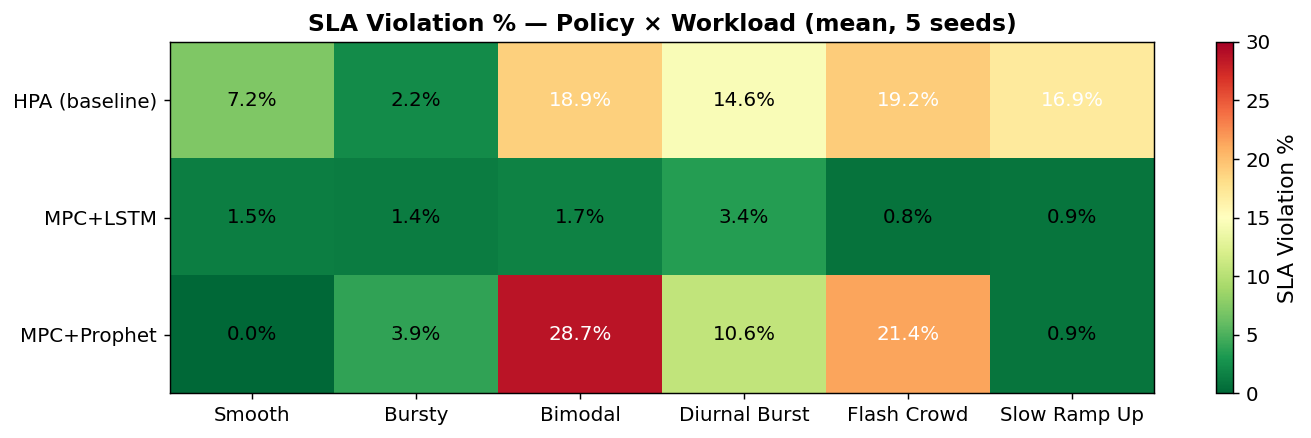

✅ Saved fig3_heatmap.png


In [70]:
# ── Figure 3: SLA Violation % Heatmap — Policy × Workload ────────────────────

HEATMAP_BATCHES = {"b1-hpa", "b2-lstm", "b3-prophet"}

configs = [c for c in POLICIES  if c in agg["config"].unique()]
wls     = [w for w in WORKLOADS if w in agg["workload"].unique()]

pivot = (
    agg[agg["batches"].str.strip().isin(HEATMAP_BATCHES)]
       .pivot(index="config", columns="workload", values="sla_pct_mean")
       .reindex(index=configs, columns=wls)
)

if pivot.empty or pivot.isna().all().all():
    print("⚠️  No data for heatmap — check aggregation")
else:
    fig, ax = plt.subplots(figsize=(11, 3.5))

    im = ax.imshow(pivot.values, aspect="auto", cmap="RdYlGn_r", vmin=0, vmax=30)

    ax.set_xticks(range(len(wls)))
    ax.set_yticks(range(len(configs)))
    ax.set_xticklabels([w.replace("_", " ").title() for w in wls], fontsize=11)
    ax.set_yticklabels([LABELS.get(c, c) for c in configs], fontsize=11)

    for i in range(len(configs)):
        for j in range(len(wls)):
            val = pivot.iloc[i, j]
            if pd.isna(val):
                txt, color = "—", "black"
            else:
                txt   = f"{val:.1f}%"
                color = "white" if val >= 15 else "black"
            ax.text(j, i, txt, ha="center", va="center", fontsize=11, color=color)

    plt.colorbar(im, ax=ax, label="SLA Violation %")
    ax.set_title(
        "SLA Violation % — Policy × Workload (mean, 5 seeds)",
        fontsize=13, fontweight="bold"
    )
    plt.tight_layout()
    plt.savefig(OUT / "fig3_heatmap.png", dpi=180)
    plt.show()
    print("✅ Saved fig3_heatmap.png")

### Figure 4 — FH-OPT A/B Comparison *(Main Novel Contribution)*

**Paper usage: §5.3 FH-OPT Ablation.** This is the most important chart in the paper. It isolates the effect of `use_fh_opt` while holding everything else constant.

Three panels show SLA, Latency, and Cost side-by-side so the reviewer can see the full tradeoff:
- If FH-OPT reduces cost with neutral/better SLA → it's a win
- If FH-OPT shows a cost-SLA tradeoff → frame it as a *configurable tradeoff mechanism*, not a bug

> **From early results (seeds 42 + 1337):** FH-OPT saves ~5 cost units on `flash_crowd` with identical SLA. On `diurnal_burst` it trades ~3pp SLA for cost savings. Full 5-seed results will confirm the pattern.

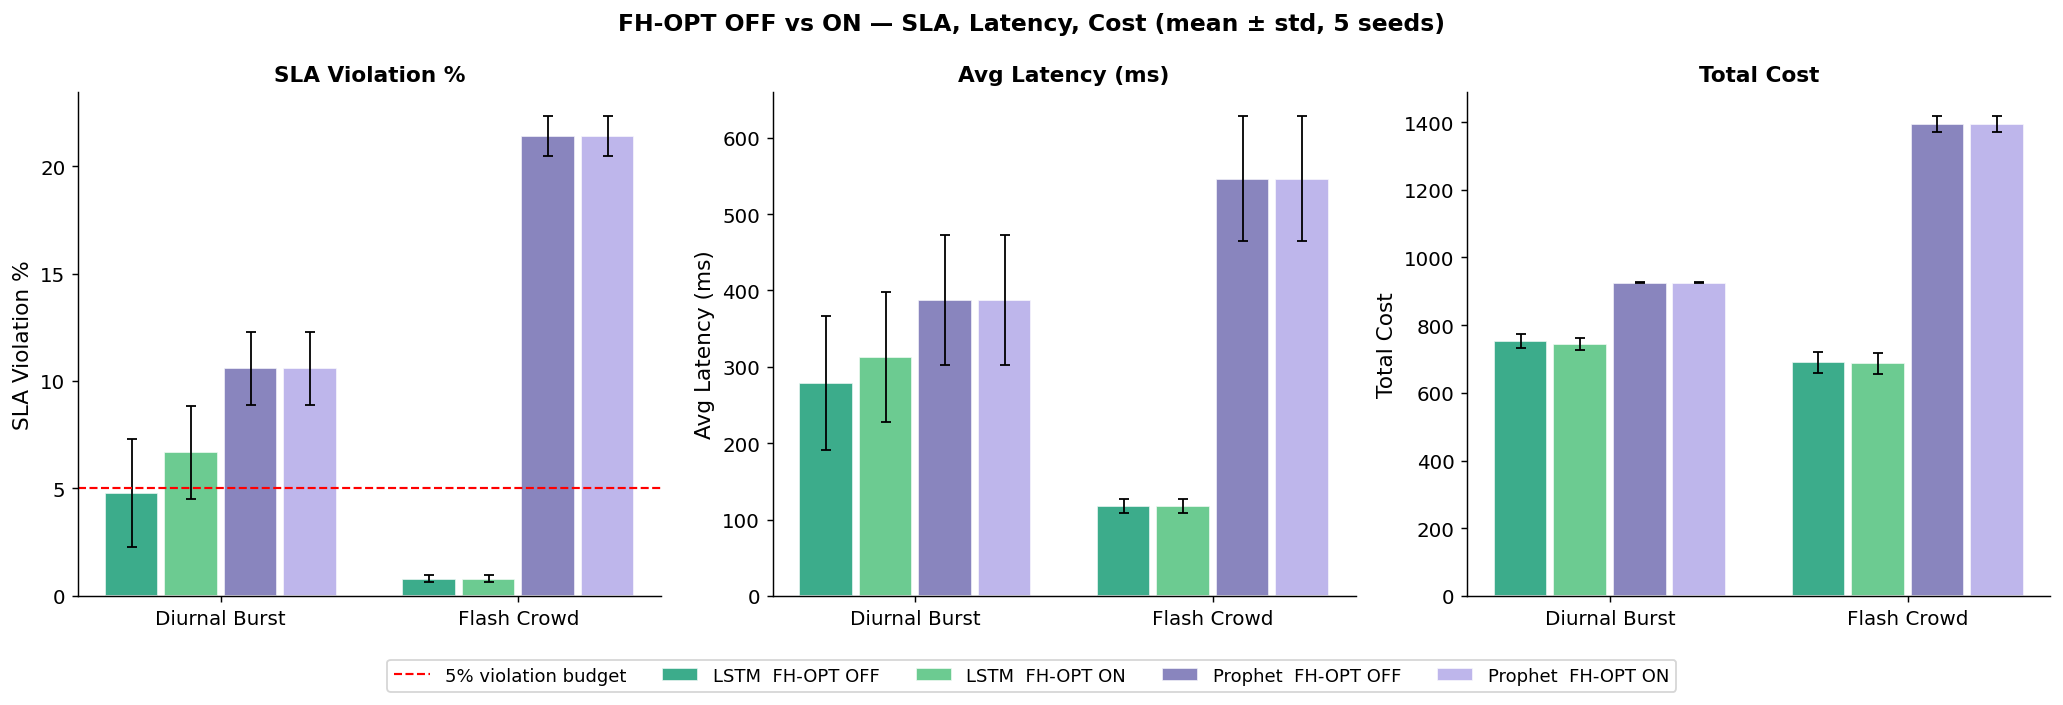

✅ Saved fig4_fhopt_ab.png


In [71]:
# ── Figure 4: FH-OPT OFF vs ON — SLA, Latency, Cost ─────────────────────────

FHOPT_BATCH  = "b7-fhopt"
FHOPT_KEYS   = ["lstm_fh_off", "lstm_fh_on", "prophet_fh_off", "prophet_fh_on"]
FHOPT_WLS    = ["diurnal_burst", "flash_crowd"]
FHOPT_METRICS = [
    ("sla_pct",        "SLA Violation %"),
    ("avg_latency_ms", "Avg Latency (ms)"),
    ("total_cost",     "Total Cost"),
]

fh_df = df[df["batch"] == FHOPT_BATCH].copy()

if fh_df.empty:
    print("⚠️  No Batch 7 data — run FH-OPT A/B tests first")
else:
    # ── Guard: check all fh_keys and workloads are present ───────────────────
    missing_keys = [k for k in FHOPT_KEYS if k not in fh_df["fh_key"].unique()]
    missing_wls  = [w for w in FHOPT_WLS  if w not in fh_df["workload"].unique()]
    if missing_keys:
        print(f"⚠️  Missing fh_keys: {missing_keys}")
    if missing_wls:
        print(f"⚠️  Missing workloads: {missing_wls}")

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    for ax, (metric, ylabel) in zip(axes, FHOPT_METRICS):
        grp = (
            fh_df.groupby(["fh_key", "workload"])[metric]
                 .agg(["mean", "std"])
                 .reset_index()
        )

        width = 0.8 / len(FHOPT_KEYS)
        x     = np.arange(len(FHOPT_WLS))

        for i, fk in enumerate(FHOPT_KEYS):
            sub   = grp[grp["fh_key"] == fk].set_index("workload")
            means = [sub.loc[w, "mean"] if w in sub.index else float("nan") for w in FHOPT_WLS]
            stds  = [sub.loc[w, "std"]  if w in sub.index else 0            for w in FHOPT_WLS]
            off   = (i - len(FHOPT_KEYS) / 2 + 0.5) * width

            ax.bar(x + off, means, width * 0.9,
                   label=LABELS[fk], color=COLORS[fk], alpha=0.85, edgecolor="white")
            ax.errorbar(x + off, means, yerr=stds,
                        fmt="none", color="black", capsize=3, linewidth=1.0)

        if metric == "sla_pct":
            ax.axhline(5, color="red", linestyle="--", linewidth=1.2, label="5% violation budget")

        ax.set_xticks(x)
        ax.set_xticklabels([w.replace("_", " ").title() for w in FHOPT_WLS], fontsize=11)
        ax.set_ylabel(ylabel, fontsize=12)
        ax.set_title(ylabel, fontsize=12, fontweight="bold")
        despine(ax)

    handles, lbls = axes[0].get_legend_handles_labels()
    fig.legend(handles, lbls,
               loc="lower center", ncol=len(FHOPT_KEYS) + 1,
               fontsize=10, bbox_to_anchor=(0.5, -0.08))
    fig.suptitle(
        "FH-OPT OFF vs ON — SLA, Latency, Cost (mean ± std, 5 seeds)",
        fontsize=13, fontweight="bold"
    )
    plt.tight_layout()
    plt.savefig(OUT / "fig4_fhopt_ab.png", dpi=180, bbox_inches="tight")
    plt.show()
    print("✅ Saved fig4_fhopt_ab.png")

### Figure 5 — FH-OPT Delta Chart

**Paper usage: §5.3, inline with the statistical test table.** The clearest single-panel proof that FH-OPT changes behaviour. **Green bar** = FH-OPT reduced SLA violations (improvement). **Red bar** = FH-OPT increased violations (tradeoff).

The annotated `+X.XXpp` values are what you quote directly in the paper text.

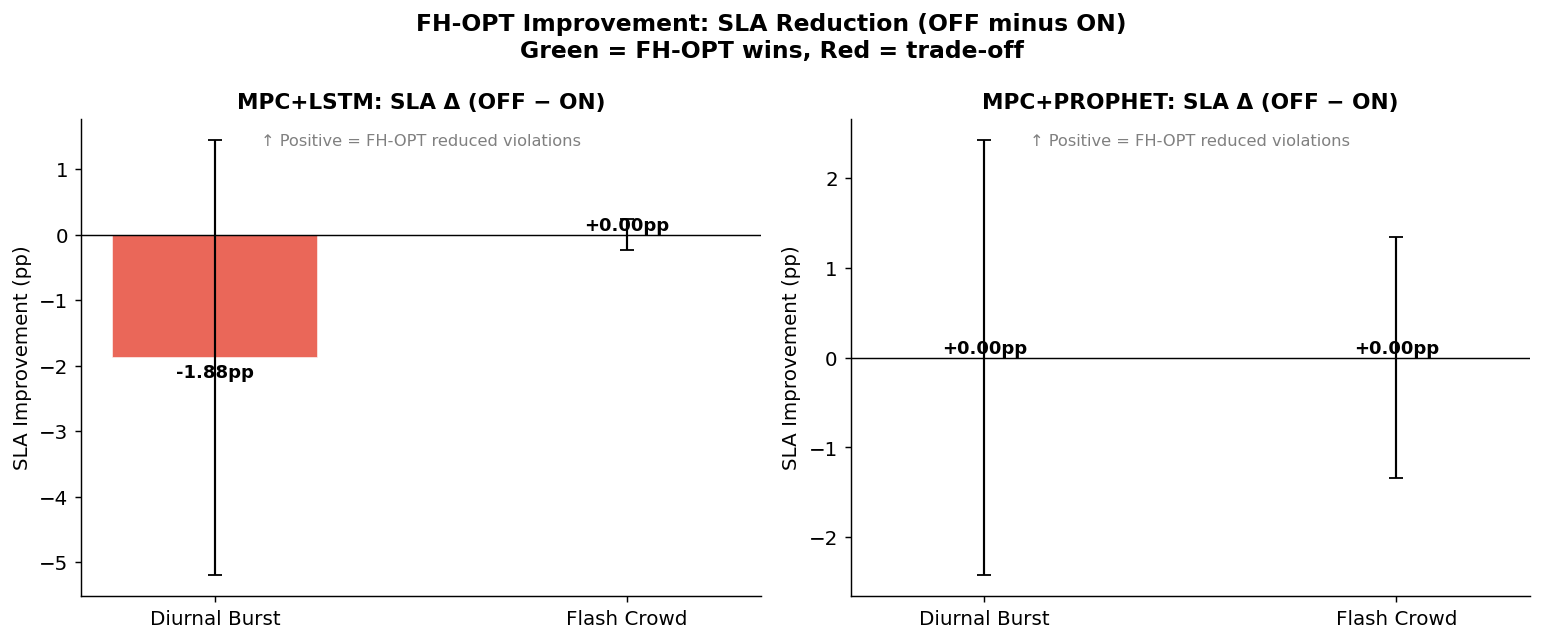

✅ Saved fig5_fhopt_delta.png


In [72]:
# ── Figure 5: FH-OPT SLA Delta (OFF − ON) per forecaster ─────────────────────

FHOPT_BATCH      = "b7-fhopt"
FHOPT_FORECASTERS = ["lstm", "prophet"]
FHOPT_WLS        = ["diurnal_burst", "flash_crowd"]

fh_df = df[df["batch"] == FHOPT_BATCH].copy()

if fh_df.empty:
    print("⚠️  No Batch 7 data — run FH-OPT A/B tests first")
else:
    missing_keys = [
        k for fc in FHOPT_FORECASTERS
        for k in [f"{fc}_fh_off", f"{fc}_fh_on"]
        if k not in fh_df["fh_key"].unique()
    ]
    if missing_keys:
        print(f"⚠️  Missing fh_keys: {missing_keys}")

    grp = (
        fh_df.groupby(["fh_key", "workload"])["sla_pct"]
             .agg(["mean", "std"])
             .reset_index()
    )

    fig, axes = plt.subplots(1, len(FHOPT_FORECASTERS), figsize=(12, 5))

    for ax, forecaster in zip(axes, FHOPT_FORECASTERS):
        deltas, errs = [], []

        for wl in FHOPT_WLS:
            off_r = grp[(grp["fh_key"] == f"{forecaster}_fh_off") & (grp["workload"] == wl)]
            on_r  = grp[(grp["fh_key"] == f"{forecaster}_fh_on")  & (grp["workload"] == wl)]

            if off_r.empty or on_r.empty:
                deltas.append(float("nan"))
                errs.append(0.0)
            else:
                d = float(off_r["mean"].values[0]) - float(on_r["mean"].values[0])
                e = (float(off_r["std"].values[0])**2 + float(on_r["std"].values[0])**2) ** 0.5
                deltas.append(d)
                errs.append(e)

        # Green = FH-OPT reduced violations, Red = FH-OPT made it worse
        colors = [
            "#2ecc71" if (not pd.isna(d) and d > 0) else "#e74c3c"
            for d in deltas
        ]
        x_labels = [w.replace("_", " ").title() for w in FHOPT_WLS]

        bars = ax.bar(x_labels, deltas, color=colors, alpha=0.85, width=0.5, edgecolor="white")
        ax.errorbar(range(len(FHOPT_WLS)), deltas, yerr=errs,
                    fmt="none", color="black", capsize=4, linewidth=1.2)
        ax.axhline(0, color="black", linewidth=0.8)

        ax.set_title(f"MPC+{forecaster.upper()}: SLA Δ (OFF − ON)",
                     fontsize=12, fontweight="bold")
        ax.set_ylabel("SLA Improvement (pp)", fontsize=11)
        ax.text(0.5, 0.97, "↑ Positive = FH-OPT reduced violations",
                transform=ax.transAxes, ha="center", va="top",
                fontsize=9, color="gray")
        despine(ax)

        for bar, d in zip(bars, deltas):
            if not pd.isna(d):
                nudge = 0.05 * max(abs(d), 0.1)
                va    = "bottom" if d >= 0 else "top"
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    d + (nudge if d >= 0 else -nudge),
                    f"{d:+.2f}pp",
                    ha="center", va=va, fontsize=10, fontweight="bold"
                )

    fig.suptitle(
        "FH-OPT Improvement: SLA Reduction (OFF minus ON)\n"
        "Green = FH-OPT wins, Red = trade-off",
        fontsize=13, fontweight="bold"
    )
    plt.tight_layout()
    plt.savefig(OUT / "fig5_fhopt_delta.png", dpi=180)
    plt.show()
    print("✅ Saved fig5_fhopt_delta.png")

### Figure 6 — Latency & Cost by Policy

**Paper usage: §5.1, supporting evidence.** Shows the cost of MPC's proactive provisioning — slightly higher replica count means slightly higher cost, but latency drops significantly under burst workloads. Use this to argue the cost increase is justified by the latency reduction.

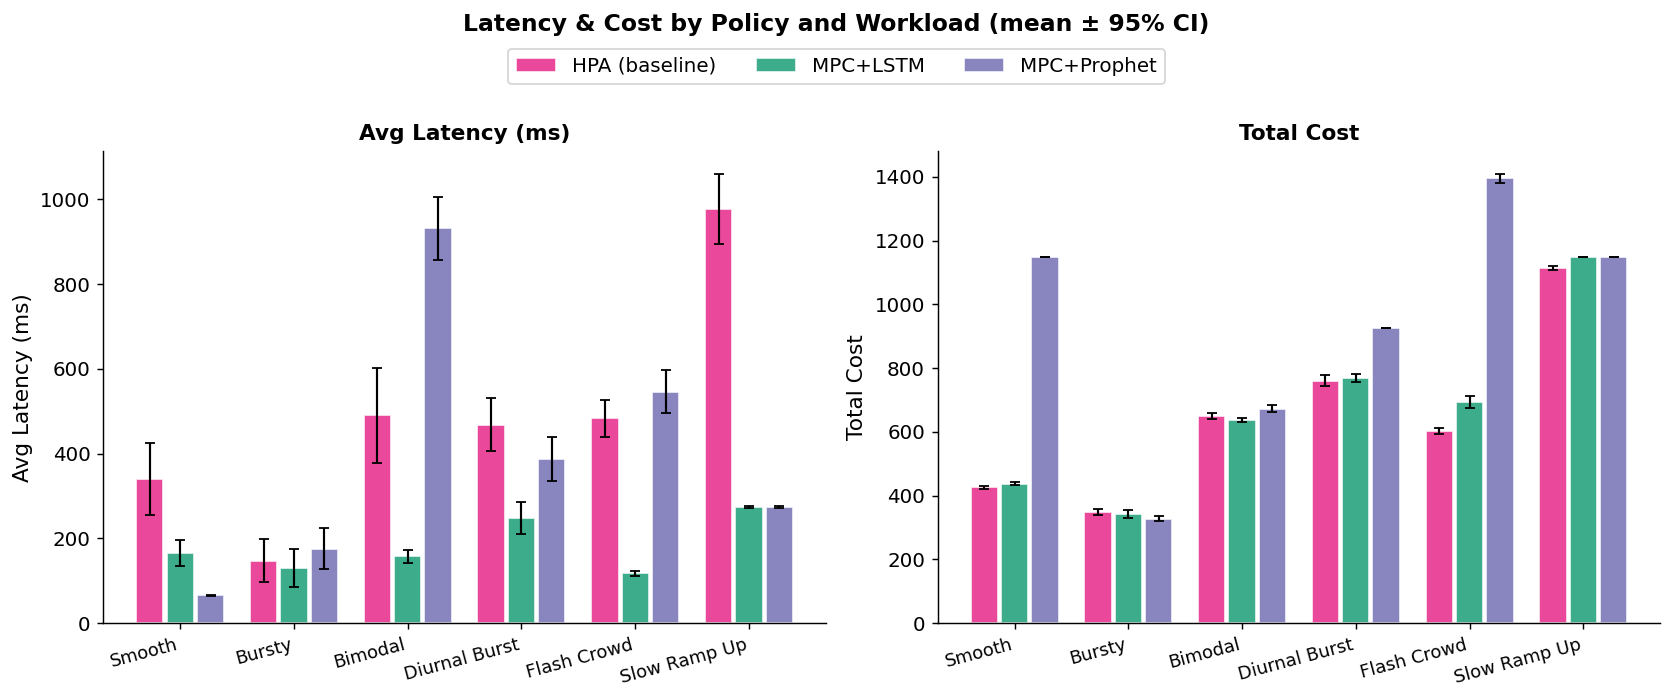

✅ Saved fig6_latency_cost.png


In [75]:
# ── Figure 6: Latency & Cost by Policy and Workload ───────────────────────────

MAIN_BATCHES  = {"b1-hpa", "b2-lstm", "b3-prophet"}
FIG6_METRICS  = [
    ("avg_latency_ms", "Avg Latency (ms)"),
    ("total_cost",     "Total Cost"),
]

# ── Filter on raw df first, then re-aggregate for Fig 6 only ─────────────────
df_main  = df[df["batch"].isin(MAIN_BATCHES)]
agg_main = (
    df_main.groupby(["config", "workload"])
           .agg(
               avg_latency_ms_mean=("avg_latency_ms", "mean"),
               avg_latency_ms_ci95=("avg_latency_ms", lambda x: 1.96 * x.std() / len(x)**0.5),
               total_cost_mean    =("total_cost",      "mean"),
               total_cost_ci95    =("total_cost",      lambda x: 1.96 * x.std() / len(x)**0.5),
           )
           .reset_index()
)

configs = [c for c in POLICIES  if c in agg_main["config"].unique()]
wls     = [w for w in WORKLOADS if w in agg_main["workload"].unique()]

if not configs or not wls:
    print("⚠️  No data for Fig 6 — check batch names and POLICIES/WORKLOADS lists")
else:
    missing_metrics = [
        f"{m}_{s}" for m, _ in FIG6_METRICS
        for s in ["mean", "ci95"]
        if f"{m}_{s}" not in agg_main.columns
    ]
    if missing_metrics:
        print(f"⚠️  Missing columns in agg_main: {missing_metrics}")

    width = 0.8 / len(configs)
    x     = np.arange(len(wls))

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    for ax, (metric, ylabel) in zip(axes, FIG6_METRICS):
        for i, cfg in enumerate(configs):
            sub   = agg_main[agg_main["config"] == cfg].set_index("workload")
            means = [
                sub.loc[w, f"{metric}_mean"] if w in sub.index else float("nan")
                for w in wls
            ]
            cis   = [
                sub.loc[w, f"{metric}_ci95"] if w in sub.index else 0.0
                for w in wls
            ]
            off = (i - len(configs) / 2 + 0.5) * width

            ax.bar(x + off, means, width * 0.9,
                   label=LABELS.get(cfg, cfg), color=COLORS.get(cfg, "gray"),
                   alpha=0.85, edgecolor="white")
            ax.errorbar(x + off, means, yerr=cis,
                        fmt="none", color="black", capsize=3, linewidth=1.2)

        ax.set_xticks(x)
        ax.set_xticklabels(
            [w.replace("_", " ").title() for w in wls],
            fontsize=10, rotation=15, ha="right"
        )
        ax.set_ylabel(ylabel, fontsize=12)
        ax.set_title(ylabel, fontsize=12, fontweight="bold")
        despine(ax)

    handles, lbls = axes[0].get_legend_handles_labels()
    fig.legend(handles, lbls,
               loc="upper center", ncol=len(configs),
               fontsize=11, bbox_to_anchor=(0.5, 1.03))
    fig.suptitle(
        "Latency & Cost by Policy and Workload (mean ± 95% CI)",
        fontsize=13, fontweight="bold", y=1.07
    )
    plt.tight_layout()
    plt.savefig(OUT / "fig6_latency_cost.png", dpi=180, bbox_inches="tight")
    plt.show()
    print("✅ Saved fig6_latency_cost.png")

---
## ✅ Section 6 — Output Summary

Lists all saved files with sizes. Everything in `paper_figures/` is ready to paste into the paper draft.

| File | Used in |
|------|---------|
| `fig1_sla_bars.png` | §5.1 Main Results |
| `fig2_coldstart.png` | §5.2 Cold-Start Analysis |
| `fig3_heatmap.png` | §5.1 or Appendix |
| `fig4_fhopt_ab.png` | §5.3 FH-OPT Ablation |
| `fig5_fhopt_delta.png` | §5.3 alongside Table 3 |
| `fig6_latency_cost.png` | §5.1 Supporting |
| `table1_sla.csv` | §5.1 Table 1 |
| `summary_table.csv` | §5.1 opening paragraph |
| `table2_fhopt_stats.csv` | §5.3 Table 2 |
| `all_runs_raw.csv` | Reproducibility / appendix |

In [76]:
files = sorted(OUT.iterdir())
print(f"✅ All outputs in ./{OUT}/   ({len(files)} files)\n")
for f in files:
    print(f"   {f.name:<38} {f.stat().st_size/1024:6.1f} KB")

✅ All outputs in ./paper_figures/   (11 files)

   aggregated.csv                            4.2 KB
   all_runs_raw.csv                         32.3 KB
   fig1_sla_bars.png                        76.0 KB
   fig2_coldstart.png                       98.5 KB
   fig3_heatmap.png                         86.4 KB
   fig4_fhopt_ab.png                       100.9 KB
   fig5_fhopt_delta.png                     69.0 KB
   fig6_latency_cost.png                    99.8 KB
   summary_table.csv                         0.1 KB
   table1_sla.csv                            0.2 KB
   table2_fhopt_stats.csv                    0.3 KB
